# Semantic Filter Ablation

The reference constructor (`scripts/crs_reference.py`, verbatim from notebooks 2, 3 and 5) called with tau = -1 gives the pure co-word network; with tau = 0.40 it gives the published CRS. Backbone (w >= 20) and Louvain (seed 42) are held fixed, so the difference isolates the semantic constraint (Section IV-C2, Table 7; Figure 3; Table 6 with the seven support thresholds of notebook 3).

Input: `EID_KEYWORDS.xlsx`. Outputs in `results/e9_semantic_filter_ablation/`. Gate: the tau = 0.40 graph must reproduce the published CRS exactly (56,635 nodes, 109,022 edges; backbone 408/608, modularity 0.356044, 7 communities).

In [1]:
# ============================================================
# CONFIGURATION AND IMPORTS
# ============================================================
import os
os.environ["OMP_NUM_THREADS"] = "4"      # several notebooks may run concurrently on one machine

import contextlib, io, itertools, json, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
torch.set_num_threads(4)

sys.path.insert(0, "scripts")
import common as C
from crs_reference import build_backbone, build_crs_for_tau

KEYWORDS = "EID_KEYWORDS.xlsx"
OUT = Path("results/e9_semantic_filter_ablation")
OUT.mkdir(parents=True, exist_ok=True)

W_SWEEP = [1, 2, 3, 5, 8, 10, 15, 20, 25, 30, 40, 50]   # extended sweep, both graphs
W_PAPER = [1, 3, 5, 8, 10, 20, 30]                       # thresholds of Table 6 (notebook 3)
LOUVAIN_SEEDS = list(range(42, 52))                      # seed 42 is the published one
SIM_BINS = np.round(np.arange(-0.2, 1.0001, 0.05), 2)   # histogram bins of Figure 3
THREADS = 4

C.set_seeds()
T = C.Timer()
meta = C.env_metadata(experiment="E9 semantic filter ablation",
                      inputs={"keywords": {"path": KEYWORDS, "sha256": C.sha256(KEYWORDS)}},
                      llm_calls=0, paid_api_calls=0)

print(f"tau = {C.TAU_EDGE} | backbone w >= {C.W_BACKBONE} | Louvain seed {C.SEED}")
print(f"embedding model: {C.MODEL_NAME} @ {C.MODEL_REVISION[:12]}")
print(f"input SHA-256: {meta['inputs']['keywords']['sha256']}")

/home/mat/academic-writing/papers/from_text_to_structure/data_repo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tau = 0.4 | backbone w >= 20 | Louvain seed 42
embedding model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 @ e8f8c211226b
input SHA-256: a440b7cedabea950ddb0be27610e1a58f747191ae08999801d73994f9d801c8c


In [2]:
# ============================================================
# KEYWORD SETS AND VOCABULARY EMBEDDINGS
# ============================================================
kw = C.load_keywords_xlsx(Path(KEYWORDS), notebook_semantics=True)
docs = [k for k in kw["keywords"] if len(k) > 0]           # notebook 2 drops empty lists
n_docs = len(docs)
vocab = sorted(set(itertools.chain.from_iterable(docs)))
print(f"documents={n_docs} vocabulary={len(vocab)}")
T.mark("load")

model = C.load_embedder(threads=THREADS)
# The batch progress bar of sentence-transformers does not render in an executed notebook.
with contextlib.redirect_stderr(io.StringIO()):
    emb = C.embed_unique(model, vocab, batch_size=256, normalize=True, desc="vocabulary")
T.mark("embeddings")
print(f"embedded {len(emb)} unique keywords (dimension {len(next(iter(emb.values())))}) "
      f"in {T.marks['embeddings'] - T.marks['load']:.0f} s")

documents=52946 vocabulary=56635


embedded 56635 unique keywords (dimension 384) in 768 s


In [3]:
# ============================================================
# GLOBAL GRAPHS, BACKBONES AND REPRODUCTION GATE
# ============================================================
def backbone_block(G, wmin, seeds=(C.SEED,)):
    """Backbone at support wmin with Louvain over several seeds (seed 42 first)."""
    H = build_backbone(G, wmin)
    s = C.graph_summary(H)
    parts, qs, ncs = {}, [], []
    for sd in seeds:
        p, q = C.louvain_partition(H, sd)
        parts[sd] = p
        qs.append(q)
        ncs.append(len(set(p.values())) if p else 0)
    s.update({
        "w_min": wmin,
        "modularity_seed42": qs[0],
        "communities_seed42": ncs[0],
        "modularity_mean": float(np.nanmean(qs)) if len(qs) > 1 else qs[0],
        "modularity_sd": float(np.nanstd(qs, ddof=1)) if len(qs) > 1 else float("nan"),
        "communities_mean": float(np.mean(ncs)) if len(ncs) > 1 else ncs[0],
        "total_weight": float(sum(d["weight"] for _, _, d in H.edges(data=True))),
    })
    return H, s, parts[seeds[0]]


G40 = build_crs_for_tau(docs, emb, C.TAU_EDGE)     # published CRS
T.mark("build_tau040")
G00 = build_crs_for_tau(docs, emb, -1.0)           # co-word: every co-occurring pair
T.mark("build_coword")

summ40, summ00 = C.graph_summary(G40), C.graph_summary(G00)
H40, bb40, part40 = backbone_block(G40, C.W_BACKBONE, LOUVAIN_SEEDS)
H00, bb00, part00 = backbone_block(G00, C.W_BACKBONE, LOUVAIN_SEEDS)
T.mark("backbones")

ref = C.CRS_REFERENCE
gate = {
    "analyzed_documents": (n_docs, ref["analyzed_documents"]),
    "nodes": (summ40["nodes"], ref["nodes"]),
    "edges": (summ40["edges"], ref["edges"]),
    "components": (summ40["components"], ref["components"]),
    "lcc_nodes": (summ40["lcc_nodes"], ref["lcc_nodes"]),
    "backbone_nodes": (bb40["nodes"], ref["backbone_nodes"]),
    "backbone_edges": (bb40["edges"], ref["backbone_edges"]),
    "backbone_communities": (bb40["communities_seed42"], ref["backbone_communities"]),
}
checks = {k: {"observed": o, "reference": r, "pass": o == r} for k, (o, r) in gate.items()}
checks["backbone_modularity"] = {
    "observed": bb40["modularity_seed42"], "reference": ref["backbone_modularity"],
    "pass": abs(bb40["modularity_seed42"] - ref["backbone_modularity"]) < 1e-6}
gate_pass = all(v["pass"] for v in checks.values())

print("REPRODUCTION GATE (tau=0.40):", "PASS" if gate_pass else "FAIL")
for k, v in checks.items():
    print(f"  {k:22s} observed={v['observed']} reference={v['reference']} {'ok' if v['pass'] else 'MISMATCH'}")
print(f"\nco-word network (tau=-1): nodes={summ00['nodes']} edges={summ00['edges']} "
      f"components={summ00['components']} lcc_fraction={summ00['lcc_fraction']:.4f} "
      f"backbone={bb00['nodes']}/{bb00['edges']} Q={bb00['modularity_seed42']:.4f} "
      f"communities={bb00['communities_seed42']}")
assert gate_pass, "the tau = 0.40 graph does not reproduce the published CRS; nothing below is interpretable"

REPRODUCTION GATE (tau=0.40): PASS
  analyzed_documents     observed=52946 reference=52946 ok
  nodes                  observed=56635 reference=56635 ok
  edges                  observed=109022 reference=109022 ok
  components             observed=19856 reference=19856 ok
  lcc_nodes              observed=34316 reference=34316 ok
  backbone_nodes         observed=408 reference=408 ok
  backbone_edges         observed=608 reference=608 ok
  backbone_communities   observed=7 reference=7 ok
  backbone_modularity    observed=0.3560443171946043 reference=0.3560443171946043 ok

co-word network (tau=-1): nodes=56635 edges=377144 components=103 lcc_fraction=0.9911 backbone=658/1108 Q=0.3098 communities=7


In [4]:
# ============================================================
# EFFECT OF THE FILTER ON CO-OCCURRENCE INSTANCES AND DISTINCT PAIRS
# ============================================================
# Every edge of G00 carries the mean cosine of its instances; G40 keeps the instances with cos >= 0.40.
rows = []
for u, v, d in G00.edges(data=True):
    kept = G40.get_edge_data(u, v)
    rows.append((u, v, d["weight"], d["sim_mean"], kept["weight"] if kept else 0))
E = pd.DataFrame(rows, columns=["u", "v", "weight_coword", "sim_mean", "weight_tau040"])
E["removed_instances"] = E["weight_coword"] - E["weight_tau040"]
total_inst = int(E["weight_coword"].sum())
kept_inst = int(E["weight_tau040"].sum())
fully_removed = E[E["weight_tau040"] == 0]
filter_effect = {
    "cooccurrence_edge_instances_total": total_inst,
    "edge_instances_kept_tau040": kept_inst,
    "edge_instances_removed": total_inst - kept_inst,
    "share_instances_removed": 1 - kept_inst / total_inst,
    "unique_edges_coword": int(len(E)),
    "unique_edges_tau040": int(summ40["edges"]),
    "unique_edges_fully_removed": int(len(fully_removed)),
    "share_unique_edges_removed": len(fully_removed) / len(E),
    "removed_edges_with_weight_ge_20": int((fully_removed["weight_coword"] >= 20).sum()),
    "removed_edges_with_weight_ge_5": int((fully_removed["weight_coword"] >= 5).sum()),
}
print("FILTER EFFECT")
for k, v in filter_effect.items():
    print(f"  {k:36s} {v:.4f}" if isinstance(v, float) else f"  {k:36s} {v}")

# Highest-support co-occurrences that the semantic filter discards (examples quoted in the paper).
removed_top = fully_removed.sort_values("weight_coword", ascending=False).head(60)
removed_top.to_csv(OUT / "removed_edges_top60.csv", index=False)
# Highest-support co-occurrences that survive (contrast).
E[E["weight_tau040"] > 0].sort_values("weight_tau040", ascending=False).head(60).to_csv(
    OUT / "kept_edges_top60.csv", index=False)
print("\nTop 10 removed pairs by support:")
print(removed_top.head(10).to_string(index=False))

# Similarity distribution of all co-occurring pairs (unique edges and edge instances), Figure 3.
cats = pd.cut(E["sim_mean"], SIM_BINS, include_lowest=True)
dist = E.groupby(cats, observed=False).agg(unique_edges=("u", "size"),
                                          edge_instances=("weight_coword", "sum")).reset_index()
dist.columns = ["sim_mean_bin", "unique_edges", "edge_instances"]
dist["cum_share_instances"] = dist["edge_instances"].cumsum() / total_inst
dist.to_csv(OUT / "similarity_distribution.csv", index=False)
T.mark("filter_effect")
print("\nCosine similarity of co-occurring pairs (bins of width 0.05):")
print(dist.to_string(index=False))

FILTER EFFECT
  cooccurrence_edge_instances_total    529000
  edge_instances_kept_tau040           183495
  edge_instances_removed               345505
  share_instances_removed              0.6531
  unique_edges_coword                  377144
  unique_edges_tau040                  109022
  unique_edges_fully_removed           268122
  share_unique_edges_removed           0.7109
  removed_edges_with_weight_ge_20      500
  removed_edges_with_weight_ge_5       4089

Top 10 removed pairs by support:
                    u                             v  weight_coword  sim_mean  weight_tau040  removed_instances
mathematics education               problem solving            732  0.303504              0                732
mathematics education      professional development            516  0.343060              0                516
mathematics education          pre-service teachers            384  0.362488              0                384
mathematics education             critical thinking  


Cosine similarity of co-occurring pairs (bins of width 0.05):
   sim_mean_bin  unique_edges  edge_instances  cum_share_instances
(-0.201, -0.15]             1               1             0.000002
  (-0.15, -0.1]            47              52             0.000100
  (-0.1, -0.05]           342             368             0.000796
  (-0.05, -0.0]          1770            1964             0.004509
   (-0.0, 0.05]          6460            7345             0.018393
    (0.05, 0.1]         16488           19753             0.055733
    (0.1, 0.15]         29638           35504             0.122849
    (0.15, 0.2]         41253           51943             0.221040
    (0.2, 0.25]         47534           59662             0.333822
    (0.25, 0.3]         46816           60292             0.447796
    (0.3, 0.35]         42203           59122             0.559558
    (0.35, 0.4]         35570           49499             0.653129
    (0.4, 0.45]         28787           44178             0.736641

In [5]:
# ============================================================
# BACKBONE COMPARISON: SHARED CONCEPTS, PARTITION AGREEMENT, HUB DOMINANCE
# ============================================================
nodes40, nodes00 = set(H40.nodes()), set(H00.nodes())
bb_compare = {
    "coword_backbone_nodes": len(nodes00), "tau040_backbone_nodes": len(nodes40),
    "shared_nodes": len(nodes00 & nodes40),
    "nodes_only_in_coword_backbone": len(nodes00 - nodes40),
    "nodes_only_in_tau040_backbone": len(nodes40 - nodes00),
    "coword_backbone_edges_removed_by_filter": int(sum(
        1 for u, v in H00.edges() if not H40.has_edge(u, v))),
    "coword_backbone_edges_total": H00.number_of_edges(),
    "partition_agreement_shared_nodes": C.partition_agreement(part00, part40),
}


def hub_stats(H):
    """How much of a backbone hangs on its most connected concept."""
    if H.number_of_nodes() == 0:
        return {}
    hub = max(H.degree(), key=lambda t: t[1])[0]
    return {"hub": hub, "hub_degree": H.degree(hub), "hub_share_of_edges": H.degree(hub) / H.number_of_edges(),
            "hub_weighted_degree_share": H.degree(hub, weight="weight") / sum(d["weight"] for _, _, d in H.edges(data=True)),
            "edges_not_incident_to_hub": H.number_of_edges() - H.degree(hub)}


hub00, hub40 = hub_stats(H00), hub_stats(H40)
hub_name = hub00.get("hub")
inc = E[(E.u == hub_name) | (E.v == hub_name)]
bb_compare["hub_dominance"] = {
    "coword_backbone": hub00, "tau040_backbone": hub40,
    "share_removed_instances_incident_to_hub": float(inc.removed_instances.sum() / max(1, E.removed_instances.sum())),
    "share_hub_instances_removed": float(inc.removed_instances.sum() / max(1, inc.weight_coword.sum())),
    "share_removed_instances_not_incident_to_hub": float(1 - inc.removed_instances.sum() / max(1, E.removed_instances.sum())),
}
bb_compare["null_placeholder_node"] = {
    "in_global_graph": G00.has_node("null"),
    "doc_freq": G00.nodes["null"]["doc_freq"] if G00.has_node("null") else 0,
    "in_coword_backbone": H00.has_node("null"), "in_tau040_backbone": H40.has_node("null"),
    "coword_backbone_degree": H00.degree("null") if H00.has_node("null") else 0,
}
# Removed edges whose endpoints are both outside the hub (are non-hub relations also discarded?).
removed_non_hub = fully_removed[(fully_removed.u != hub_name) & (fully_removed.v != hub_name)].sort_values(
    "weight_coword", ascending=False).head(60)
removed_non_hub.to_csv(OUT / "removed_edges_top60_excluding_hub.csv", index=False)
pd.DataFrame(sorted(nodes00 - nodes40)).to_csv(OUT / "nodes_only_in_coword_backbone.csv",
                                              index=False, header=["keyword"])
# Community sizes and top nodes by weighted degree for both backbones.
community_sizes = {}
for tag, H, part in (("tau040", H40, part40), ("coword", H00, part00)):
    wdeg = dict(H.degree(weight="weight"))
    top = (pd.DataFrame({"keyword": list(H.nodes()),
                         "community": [part.get(n) for n in H.nodes()],
                         "degree": [H.degree(n) for n in H.nodes()],
                         "weighted_degree": [wdeg[n] for n in H.nodes()]})
           .sort_values("weighted_degree", ascending=False))
    top.to_csv(OUT / f"backbone_nodes_{tag}.csv", index=False)
    sizes = pd.Series(part).value_counts().sort_values(ascending=False)
    sizes.rename_axis("community").reset_index(name="n_keywords").to_csv(
        OUT / f"community_sizes_{tag}.csv", index=False)
    community_sizes[tag] = sizes.tolist()
T.mark("backbone_compare")

print("BACKBONE COMPARISON")
print(json.dumps(bb_compare, indent=2, default=C._json_default))
print("\ncommunity sizes (seed 42):", community_sizes)
print("\nTop 10 removed pairs not involving the hub:")
print(removed_non_hub.head(10).to_string(index=False))

BACKBONE COMPARISON
{
  "coword_backbone_nodes": 658,
  "tau040_backbone_nodes": 408,
  "shared_nodes": 408,
  "nodes_only_in_coword_backbone": 250,
  "nodes_only_in_tau040_backbone": 0,
  "coword_backbone_edges_removed_by_filter": 500,
  "coword_backbone_edges_total": 1108,
  "partition_agreement_shared_nodes": {
    "shared_nodes": 408,
    "nmi": 0.7025558681462132,
    "ari": 0.8341680810309227
  },
  "hub_dominance": {
    "coword_backbone": {
      "hub": "mathematics education",
      "hub_degree": 581,
      "hub_share_of_edges": 0.5243682310469314,
      "hub_weighted_degree_share": 0.6219276222154703,
      "edges_not_incident_to_hub": 527
    },
    "tau040_backbone": {
      "hub": "mathematics education",
      "hub_degree": 313,
      "hub_share_of_edges": 0.5148026315789473,
      "hub_weighted_degree_share": 0.6152109020116807,
      "edges_not_incident_to_hub": 295
    },
    "share_removed_instances_incident_to_hub": 0.1421831811406492,
    "share_hub_instances_remove

In [6]:
# ============================================================
# EXTENDED w SWEEP (TWELVE THRESHOLDS, BOTH GRAPHS)
# ============================================================
# NMI/ARI compare the Louvain partition at each w with the partition at the previous w of THIS list.
sweep_rows = []
for tag, G in (("tau040", G40), ("coword", G00)):
    prev_part = None
    for w in W_SWEEP:
        H = build_backbone(G, w)
        s = C.graph_summary(H)
        part, q = C.louvain_partition(H, C.SEED)
        agree = C.partition_agreement(prev_part, part) if prev_part else {"nmi": np.nan, "ari": np.nan, "shared_nodes": 0}
        sweep_rows.append({"graph": tag, "w_min": w, **s, "modularity": q,
                           "communities": len(set(part.values())) if part else 0,
                           "nmi_vs_previous_w": agree["nmi"], "ari_vs_previous_w": agree["ari"],
                           "shared_nodes_vs_previous_w": agree["shared_nodes"]})
        prev_part = part
sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(OUT / "w_sweep.csv", index=False)
T.mark("w_sweep")

print("w SWEEP (extended threshold set)")
print(sweep[["graph", "w_min", "nodes", "edges", "components", "lcc_nodes", "lcc_fraction",
             "modularity", "communities", "nmi_vs_previous_w", "ari_vs_previous_w"]]
      .round(4).to_string(index=False))

w SWEEP (extended threshold set)
 graph  w_min  nodes  edges  components  lcc_nodes  lcc_fraction  modularity  communities  nmi_vs_previous_w  ari_vs_previous_w
tau040      1  38618 109022        1839      34316        0.8886      0.4413         2403                NaN                NaN
tau040      2   5814  15145         141       5516        0.9487      0.3738          187             0.5477             0.5571
tau040      3   3063   7214          36       2991        0.9765      0.3664           58             0.6971             0.7817
tau040      5   1627   3331          19       1588        0.9760      0.3600           34             0.7316             0.7959
tau040      8   1011   1801          11        990        0.9792      0.3560           20             0.7789             0.8363
tau040     10    783   1344           8        769        0.9821      0.3558           17             0.8861             0.9323
tau040     15    524    824           2        521        0.9943      0

In [7]:
# ============================================================
# w SWEEP ON THE SEVEN THRESHOLDS OF THE MANUSCRIPT (TABLE 6)
# ============================================================
# Same tau = 0.40 graph, same constructor, same Louvain seed. NMI/ARI are defined between consecutive
# thresholds of THIS set (w = 3 versus 1, 5 versus 3, ...), which is the definition used in Table 6.
t_paper0 = time.perf_counter()
paper_rows, prev = [], None
for w in W_PAPER:
    H = build_backbone(G40, w)
    hs = C.graph_summary(H)
    part, q = C.louvain_partition(H, C.SEED)
    agree = C.partition_agreement(prev, part) if prev else {"nmi": np.nan, "ari": np.nan, "shared_nodes": 0}
    paper_rows.append({"w_min": w, "nodes": hs["nodes"], "edges": hs["edges"], "components": hs["components"],
                       "lcc_nodes": hs["lcc_nodes"], "lcc_fraction": hs["lcc_fraction"], "modularity": q,
                       "communities": len(set(part.values())) if part else 0,
                       "nmi_vs_previous_w": agree["nmi"], "ari_vs_previous_w": agree["ari"],
                       "shared_nodes_vs_previous_w": agree["shared_nodes"]})
    prev = part
paper = pd.DataFrame(paper_rows)
paper.to_csv(OUT / "w_sweep_paper_thresholds.csv", index=False)

row_w20 = paper_rows[W_PAPER.index(C.W_BACKBONE)]          # plain Python values, as in the source script
paper_gate_ok = bool(gate_pass and abs(row_w20["modularity"] - ref["backbone_modularity"]) < 1e-6)
C.write_json({"gate": "tau=0.40 graph and w=20 backbone reproduce the published CRS", "pass": paper_gate_ok,
              "thresholds": W_PAPER, "nodes": summ40["nodes"], "edges": summ40["edges"],
              "backbone_w20": {k: row_w20[k] for k in ("nodes", "edges", "modularity", "communities")}},
             OUT / "w_sweep_paper_thresholds_validation.json")
meta_paper = C.env_metadata(experiment="E9b w sweep on the manuscript thresholds", llm_calls=0, paid_api_calls=0,
                            inputs={"keywords": {"path": KEYWORDS, "sha256": meta["inputs"]["keywords"]["sha256"]}})
meta_paper.update({"completed_utc": C.now_utc(),
                   "timings_seconds": {"w_sweep_paper_thresholds": round(time.perf_counter() - t_paper0, 3),
                                       "total": round(time.perf_counter() - T.t0, 3)},
                   "status": "complete"})
C.write_json(meta_paper, OUT / "w_sweep_paper_thresholds_metadata.json")
T.mark("w_sweep_paper_thresholds")

print("w SWEEP ON THE MANUSCRIPT THRESHOLDS (Table 6); gate:", "PASS" if paper_gate_ok else "FAIL")
print(paper.round(4).to_string(index=False))

w SWEEP ON THE MANUSCRIPT THRESHOLDS (Table 6); gate: PASS
 w_min  nodes  edges  components  lcc_nodes  lcc_fraction  modularity  communities  nmi_vs_previous_w  ari_vs_previous_w  shared_nodes_vs_previous_w
     1  38618 109022        1839      34316        0.8886      0.4413         2403                NaN                NaN                           0
     3   3063   7214          36       2991        0.9765      0.3664           58             0.5854             0.6193                        3063
     5   1627   3331          19       1588        0.9760      0.3600           34             0.7316             0.7959                        1627
     8   1011   1801          11        990        0.9792      0.3560           20             0.7789             0.8363                        1011
    10    783   1344           8        769        0.9821      0.3558           17             0.8861             0.9323                         783
    20    408    608           2        406    

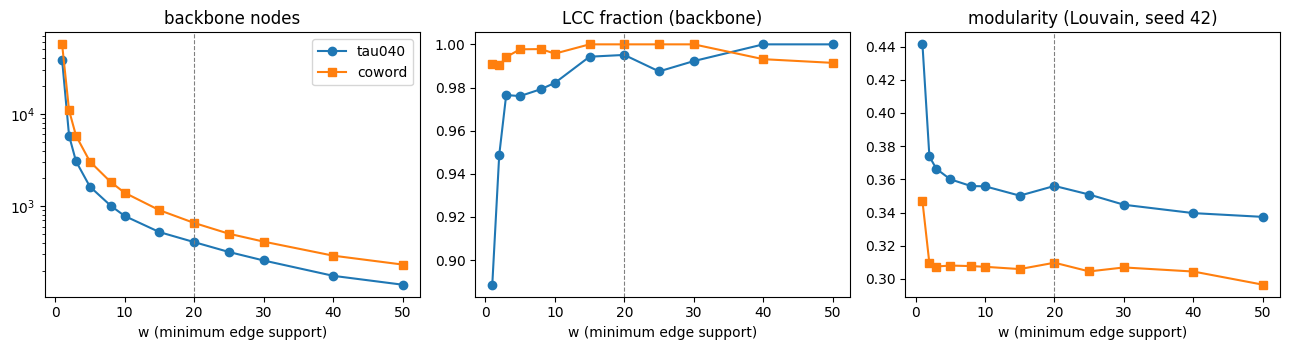

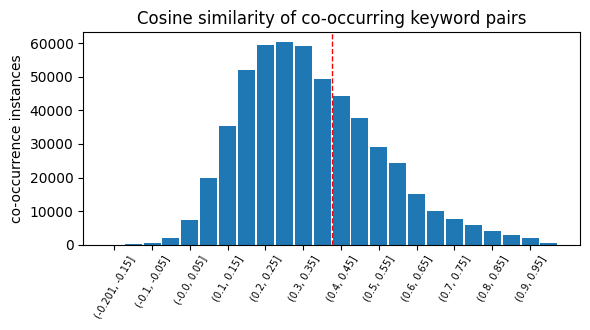

figures written: w_sweep.png/.pdf, similarity_distribution.png/.pdf (Figure 3 of the manuscript)


In [8]:
# ============================================================
# FIGURES
# ============================================================
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
    for tag, mk in (("tau040", "o"), ("coword", "s")):
        d = sweep[sweep.graph == tag]
        ax[0].plot(d.w_min, d.nodes, marker=mk, label=tag); ax[0].set_yscale("log")
        ax[1].plot(d.w_min, d.lcc_fraction, marker=mk, label=tag)
        ax[2].plot(d.w_min, d.modularity, marker=mk, label=tag)
    for a, t in zip(ax, ["backbone nodes", "LCC fraction (backbone)", "modularity (Louvain, seed 42)"]):
        a.set_xlabel("w (minimum edge support)"); a.set_title(t); a.axvline(20, ls="--", c="gray", lw=0.8)
    ax[0].legend(); fig.tight_layout(); fig.savefig(OUT / "w_sweep.png", dpi=150); fig.savefig(OUT / "w_sweep.pdf")
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 3.4))
    ax.bar(dist.index, dist.edge_instances, width=0.9)
    ax.set_xticks(dist.index[::2]); ax.set_xticklabels([str(b) for b in dist.sim_mean_bin[::2]], rotation=60, fontsize=7)
    ax.axvline(dist.index[np.searchsorted(SIM_BINS, 0.40) - 1] + 0.5, ls="--", c="red", lw=1)
    ax.set_ylabel("co-occurrence instances"); ax.set_title("Cosine similarity of co-occurring keyword pairs")
    fig.tight_layout(); fig.savefig(OUT / "similarity_distribution.png", dpi=150); fig.savefig(OUT / "similarity_distribution.pdf")
    plt.show()
    print("figures written: w_sweep.png/.pdf, similarity_distribution.png/.pdf (Figure 3 of the manuscript)")
except Exception as exc:  # figures are optional
    print("figure generation skipped:", exc)

In [9]:
# ============================================================
# SUMMARY TABLES, VALIDATION AND METADATA
# ============================================================
comparison = pd.DataFrame([
    {"graph": "coword (no semantic filter)", **summ00, **{f"backbone_{k}": v for k, v in bb00.items()}},
    {"graph": "tau=0.40 (published CRS)", **summ40, **{f"backbone_{k}": v for k, v in bb40.items()}},
])
comparison.to_csv(OUT / "comparison.csv", index=False)
summary = {"documents": n_docs, "vocabulary": len(vocab),
           "global_graph": {"coword": summ00, "tau040": summ40},
           "backbone_w20": {"coword": bb00, "tau040": bb40},
           "filter_effect": filter_effect, "backbone_comparison": bb_compare,
           "louvain_seeds": LOUVAIN_SEEDS, "w_sweep_values": W_SWEEP}
C.write_json(summary, OUT / "summary.json")
C.write_json({"gate": "tau=0.40 CRS reproduction (notebooks 2-5)", "pass": gate_pass,
              "checks": checks}, OUT / "validation.json")
meta.update({"completed_utc": C.now_utc(), "timings_seconds": T.marks, "status": "complete",
             "gate_pass": gate_pass})
C.write_json(meta, OUT / "metadata.json")

print("COMPARISON (Table 7 of the manuscript)")
print(comparison.set_index("graph").T.to_string())
print("\ntimings (s):", T.marks)
print("written:", sorted(p.name for p in OUT.iterdir()))

COMPARISON (Table 7 of the manuscript)
graph                        coword (no semantic filter)  tau=0.40 (published CRS)
nodes                                       56635.000000              56635.000000
edges                                      377144.000000             109022.000000
density                                         0.000235                  0.000068
components                                    103.000000              19856.000000
lcc_nodes                                   56129.000000              34316.000000
lcc_fraction                                    0.991066                  0.605915
lcc_edges                                  376134.000000             106297.000000
isolated_nodes                                  1.000000              18017.000000
backbone_nodes                                658.000000                408.000000
backbone_edges                               1108.000000                608.000000
backbone_density                                

## Check against the manuscript

In [10]:
# ============================================================
# MANUSCRIPT CHECK
# ============================================================
rows = []


def chk(location, quantity, tex_value, target, computed, digits=None, scale=1):
    """One check row. Floats are compared after scaling and rounding to the manuscript precision."""
    if computed is None:
        shown, ok = "not available", False
    elif isinstance(computed, (bool, np.bool_)) or isinstance(target, str):
        shown, ok = str(computed), str(computed) == str(target)
    elif isinstance(computed, (int, np.integer)):
        shown, ok = f"{int(computed):,}", int(computed) == target
    else:
        val = float(computed) * scale
        shown = f"{val:.{digits}f}" if digits is not None else f"{val}"
        ok = (round(val, digits) == target) if digits is not None else (val == target)
    rows.append({"location": location, "quantity": quantity, "main.tex": tex_value,
                 "computed": shown, "flag": "match" if ok else "differs"})


def pair(a, b):
    r = E[((E.u == a) & (E.v == b)) | ((E.u == b) & (E.v == a))]
    return r.iloc[0] if len(r) else None


agree = bb_compare["partition_agreement_shared_nodes"]
hubd = bb_compare["hub_dominance"]
nullp = bb_compare["null_placeholder_node"]
mode_bin = dist.loc[dist.edge_instances.idxmax(), "sim_mean_bin"]
P = paper.set_index("w_min")
P_3_30 = P.loc[3:30]

# --- Section III-C and Figure 3 -------------------------------------------------------------
chk("Sec. III-C, Fig. 3", "co-occurrence instances", "529,000", 529000, filter_effect["cooccurrence_edge_instances_total"])
chk("Sec. III-C, Fig. 3", "share of instances below tau = 0.40", "65.3%", 65.3, filter_effect["share_instances_removed"], 1, 100)
chk("Sec. III-C", "modal bin of the instance density", "between 0.20 and 0.35", "True",
    bool(mode_bin.left >= 0.20 - 1e-9 and mode_bin.right <= 0.35 + 1e-9))
chk("Sec. III-C", "NMI, backbone partitions on shared concepts", "0.70", 0.70, agree["nmi"], 2)
chk("Sec. III-C", "ARI, backbone partitions on shared concepts", "0.83", 0.83, agree["ari"], 2)

# --- Section III-D text and Table 6 ----------------------------------------------------------
chk("Sec. III-D", "min modularity, w = 3 to 30", "0.345", 0.345, P_3_30.modularity.min(), 3)
chk("Sec. III-D", "max modularity, w = 3 to 30", "0.366", 0.366, P_3_30.modularity.max(), 3)
chk("Sec. III-D", "LCC share at w = 1", "0.889", 0.889, P.loc[1, "lcc_fraction"], 3)
chk("Sec. III-D", "max LCC share (at w = 20)", "0.995", 0.995, P.lcc_fraction.max(), 3)
chk("Sec. III-D", "w with the max LCC share", "20", 20, int(P.lcc_fraction.idxmax()))
chk("Sec. III-D", "backbone components at w = 20", "2", 2, int(P.loc[20, "components"]))
chk("Sec. III-D", "min NMI between consecutive w", "0.59", 0.59, P.nmi_vs_previous_w.min(), 2)
chk("Sec. III-D", "max NMI between consecutive w", "0.89", 0.89, P.nmi_vs_previous_w.max(), 2)
chk("Sec. III-D", "NMI, w = 10 to 20", "0.70", 0.70, P.loc[20, "nmi_vs_previous_w"], 2)
chk("Sec. III-D", "NMI, w = 20 to 30", "0.81", 0.81, P.loc[30, "nmi_vs_previous_w"], 2)
chk("Sec. III-D", "backbone concepts at w = 20 exceed 400", "more than 400", "True", bool(P.loc[20, "nodes"] > 400))
table6 = {  # w: (nodes, edges, components, LCC nodes, LCC prop., Q, communities, NMI) as printed in Table 6
    1: (38618, 109022, 1839, 34316, 0.8886, 0.441, 2403, None),
    3: (3063, 7214, 36, 2991, 0.9765, 0.366, 58, 0.59),
    5: (1627, 3331, 19, 1588, 0.9760, 0.360, 34, 0.73),
    8: (1011, 1801, 11, 990, 0.9792, 0.356, 20, 0.78),
    10: (783, 1344, 8, 769, 0.9821, 0.356, 17, 0.89),
    20: (408, 608, 2, 406, 0.9951, 0.356, 7, 0.70),
    30: (258, 368, 2, 256, 0.9922, 0.345, 6, 0.81),
}
for w, (nn, ee, cc, ln, lp, qq, cm, nmi) in table6.items():
    r = P.loc[w]
    chk(f"Table 6, w = {w}", "nodes", f"{nn:,}", nn, int(r.nodes))
    chk(f"Table 6, w = {w}", "edges", f"{ee:,}", ee, int(r.edges))
    chk(f"Table 6, w = {w}", "components", f"{cc:,}", cc, int(r.components))
    chk(f"Table 6, w = {w}", "LCC nodes", f"{ln:,}", ln, int(r.lcc_nodes))
    chk(f"Table 6, w = {w}", "LCC proportion", f"{lp:.4f}", lp, r.lcc_fraction, 4)
    chk(f"Table 6, w = {w}", "modularity Q (seed 42)", f"{qq:.3f}", qq, r.modularity, 3)
    chk(f"Table 6, w = {w}", "communities", f"{cm:,}", cm, int(r.communities))
    if nmi is not None:
        chk(f"Table 6, w = {w}", "NMI vs previous w", f"{nmi:.2f}", nmi, r.nmi_vs_previous_w, 2)

# --- Section IV-C1 ---------------------------------------------------------------------------
chk("Sec. IV-C1", "unfiltered network: vocabulary in one component", "99.1%", 99.1, summ00["lcc_fraction"], 1, 100)
chk("Sec. IV-C1", "isolated nodes under tau = 0.40", "18,017", 18017, summ40["isolated_nodes"])
chk("Sec. IV-C1", "share of isolated nodes", "31.8%", 31.8, summ40["isolated_nodes"] / summ40["nodes"], 1, 100)
chk("Sec. IV-C1", "non-isolated nodes (w = 1 backbone)", "38,618", 38618, int(P.loc[1, "nodes"]))
chk("Sec. IV-C1", "share of non-isolated nodes", "68.2%", 68.2, 1 - summ40["isolated_nodes"] / summ40["nodes"], 1, 100)

# --- Table 7 (co-word without constraint | CRS tau = 0.40) ------------------------------------
for label, s, b, hub in (("co-word", summ00, bb00, hub00), ("tau = 0.40", summ40, bb40, hub40)):
    loc = f"Table 7, {label}"
    chk(loc, "global nodes", "56,635", 56635, s["nodes"])
    chk(loc, "global edges", "377,144" if label == "co-word" else "109,022", 377144 if label == "co-word" else 109022, s["edges"])
    chk(loc, "isolated nodes", "1" if label == "co-word" else "18,017", 1 if label == "co-word" else 18017, s["isolated_nodes"])
    chk(loc, "global LCC proportion", "0.991" if label == "co-word" else "0.606", 0.991 if label == "co-word" else 0.606, s["lcc_fraction"], 3)
    chk(loc, "backbone nodes", "658" if label == "co-word" else "408", 658 if label == "co-word" else 408, b["nodes"])
    chk(loc, "backbone edges", "1,108" if label == "co-word" else "608", 1108 if label == "co-word" else 608, b["edges"])
    chk(loc, "backbone components", "1" if label == "co-word" else "2", 1 if label == "co-word" else 2, b["components"])
    chk(loc, "backbone LCC proportion", "1.000" if label == "co-word" else "0.995", 1.000 if label == "co-word" else 0.995, b["lcc_fraction"], 3)
    chk(loc, "modularity, seed 42", "0.310" if label == "co-word" else "0.356", 0.310 if label == "co-word" else 0.356, b["modularity_seed42"], 3)
    chk(loc, "modularity, mean of 10 seeds", "0.3096" if label == "co-word" else "0.3559", 0.3096 if label == "co-word" else 0.3559, b["modularity_mean"], 4)
    chk(loc, "communities", "7", 7, b["communities_seed42"])
    chk(loc, "hub share of backbone edges", "52.4%" if label == "co-word" else "51.5%", 52.4 if label == "co-word" else 51.5, hub["hub_share_of_edges"], 1, 100)
chk("Table 7, co-word", "null in backbone", "yes (degree 3)", "True", bool(nullp["in_coword_backbone"]))
chk("Table 7, co-word", "degree of null in backbone", "3", 3, int(nullp["coword_backbone_degree"]))
chk("Table 7, tau = 0.40", "null in backbone", "no", "False", bool(nullp["in_tau040_backbone"]))

# --- Section IV-C2 text ----------------------------------------------------------------------
chk("Sec. IV-C2", "keyword sets (analysed documents)", "52,946", 52946, n_docs)
chk("Sec. IV-C2", "share of co-occurrence instances discarded", "65.3%", 65.3, filter_effect["share_instances_removed"], 1, 100)
chk("Sec. IV-C2", "distinct pairs (co-word edges)", "377,144", 377144, filter_effect["unique_edges_coword"])
chk("Sec. IV-C2", "share of distinct pairs discarded", "71.1%", 71.1, filter_effect["share_unique_edges_removed"], 1, 100)
chk("Sec. IV-C2", "discarded pairs with support >= 20", "500", 500, filter_effect["removed_edges_with_weight_ge_20"])
for a, b, sup, cos in (("mathematics education", "problem solving", 732, 0.30),
                       ("mathematics education", "professional development", 516, 0.34),
                       ("mathematics education", "pre-service teachers", 384, 0.36),
                       ("engineering education", "problem solving", 168, 0.17),
                       ("stem education", "computational thinking", 151, 0.19)):
    r = pair(a, b)
    chk("Sec. IV-C2", f"'{a}' with '{b}': support (fully removed)", f"{sup:,}", sup,
        None if r is None or r.weight_tau040 != 0 else int(r.weight_coword))
    chk("Sec. IV-C2", f"'{a}' with '{b}': mean cosine", f"{cos:.2f}", cos, None if r is None else r.sim_mean, 2)
chk("Sec. IV-C2", "top removed pair is the one quoted first", "mathematics education / problem solving",
    "mathematics education / problem solving", " / ".join(sorted([removed_top.iloc[0].u, removed_top.iloc[0].v])))
chk("Sec. IV-C2", "discarded instances incident to the hub", "14.2%", 14.2, hubd["share_removed_instances_incident_to_hub"], 1, 100)
chk("Sec. IV-C2", "discarded instances not incident to the hub", "85.8%", 85.8, hubd["share_removed_instances_not_incident_to_hub"], 1, 100)
chk("Sec. IV-C2", "tau = 0.40 backbone concepts also in the co-word backbone", "all 408", 408, bb_compare["shared_nodes"])
chk("Sec. IV-C2", "tau = 0.40 backbone concepts absent from the co-word backbone", "0 (implied)", 0, bb_compare["nodes_only_in_tau040_backbone"])
chk("Sec. IV-C2", "co-word backbone concepts", "658", 658, bb_compare["coword_backbone_nodes"])
chk("Sec. IV-C2", "NMI on shared concepts", "0.70", 0.70, agree["nmi"], 2)
chk("Sec. IV-C2", "ARI on shared concepts", "0.83", 0.83, agree["ari"], 2)
chk("Sec. IV-C2", "modularity SD over 10 seeds, co-word, below 0.0005", "below 0.0005", "True", bool(bb00["modularity_sd"] < 0.0005))
chk("Sec. IV-C2", "modularity SD over 10 seeds, tau = 0.40, below 0.0005", "below 0.0005", "True", bool(bb40["modularity_sd"] < 0.0005))
chk("Sec. IV-C2", "hub of both backbones", "mathematics education", "mathematics education",
    hub00["hub"] if hub00["hub"] == hub40["hub"] else f"{hub00['hub']} / {hub40['hub']}")

# --- Section IV-D1 (published backbone, reproduced here) ---------------------------------------
chk("Sec. IV-D1", "communities (seed 42)", "7", 7, bb40["communities_seed42"])
chk("Sec. IV-D1", "modularity", "0.356", 0.356, bb40["modularity_seed42"], 3)
chk("Sec. IV-D1", "three largest communities", "274, 72, 42", "274, 72, 42", ", ".join(str(x) for x in community_sizes["tau040"][:3]))
chk("Sec. IV-D1", "degree of 'mathematics education'", "313", 313, int(hub40["hub_degree"]))

# --- Section IV-D2 reproduction statement, abstract, Section V ----------------------------------
chk("Sec. IV-D2", "reproduced modularity", "0.356044", 0.356044, bb40["modularity_seed42"], 6)
chk("Sec. IV-D2", "reproduced communities", "seven", 7, bb40["communities_seed42"])
chk("Abstract", "share of raw co-occurrence links removed", "65%", 65.0, filter_effect["share_instances_removed"], 0, 100)
chk("Abstract", "ARI", "0.83", 0.83, agree["ari"], 2)
chk("Abstract", "modularity", "0.356", 0.356, bb40["modularity_seed42"], 3)
chk("Sec. V", "modularity co-word", "0.31", 0.31, bb00["modularity_seed42"], 2)
chk("Sec. V", "modularity tau = 0.40", "0.36", 0.36, bb40["modularity_seed42"], 2)
chk("Sec. V", "ARI", "0.83", 0.83, agree["ari"], 2)

check = pd.DataFrame(rows)
pd.set_option("display.width", 250)
print(check.to_string(index=False))
n_diff = int((check.flag == "differs").sum())
print(f"\n{len(check)} checks: {len(check) - n_diff} match, {n_diff} differ")

           location                                                                         quantity                                main.tex                                computed  flag
 Sec. III-C, Fig. 3                                                          co-occurrence instances                                 529,000                                 529,000 match
 Sec. III-C, Fig. 3                                              share of instances below tau = 0.40                                   65.3%                                    65.3 match
         Sec. III-C                                                modal bin of the instance density                   between 0.20 and 0.35                                    True match
         Sec. III-C                                      NMI, backbone partitions on shared concepts                                    0.70                                    0.70 match
         Sec. III-C                                      ARI, bac